In [3]:
import zipfile
import os

# Directory where the uploaded files are located
directory_to_unzip = '/content/'

# List all files in the directory
files_in_dir = os.listdir(directory_to_unzip)

for filename in files_in_dir:
    if filename.endswith('.zip'):
        zip_filepath = os.path.join(directory_to_unzip, filename)
        print(f"Attempting to unzip: {zip_filepath}")
        try:
            with zipfile.ZipFile(zip_filepath, 'r') as zip_ref:
                zip_ref.extractall(directory_to_unzip)
            print(f"Successfully unzipped {filename}")
            # Optional: Remove the zip file after extraction
            # os.remove(zip_filepath)
        except zipfile.BadZipFile:
            print(f"Error: {filename} is not a valid zip file.")
        except Exception as e:
            print(f"An error occurred while unzipping {filename}: {e}")

Attempting to unzip: /content/real face dataset.zip
Successfully unzipped real face dataset.zip
Attempting to unzip: /content/synthetic data.zip
Successfully unzipped synthetic data.zip


# Task
Print 5 images from each class or folder from both datasets located in "/content/real and fake face" and "/content/synthetic data".

## Identify dataset directories

### Subtask:
Locate the root directories of the unzipped "real face dataset" and "synthetic data" within the `/content/` directory.


**Reasoning**:
List the contents of the `/content/` directory to identify the unzipped folders and assign the paths to variables.



In [4]:
import os

# List contents of /content/
content_files = os.listdir('/content/')
print("Contents of /content/:", content_files)

# Identify the unzipped directories
real_face_dir = None
synthetic_data_dir = None

for item in content_files:
    item_path = os.path.join('/content/', item)
    if os.path.isdir(item_path):
        if "real face dataset" in item.lower():
            real_face_dir = item_path
        elif "synthetic data" in item.lower():
            synthetic_data_dir = item_path

print("Real face dataset directory:", real_face_dir)
print("Synthetic data directory:", synthetic_data_dir)

Contents of /content/: ['.config', 'real face dataset.zip', 'synthetic data.zip', 'real face dataset', 'synthetic data', 'sample_data']
Real face dataset directory: /content/real face dataset
Synthetic data directory: /content/synthetic data


## List subdirectories

### Subtask:
Get a list of all subdirectories within each dataset directory. These subdirectories represent the different classes or folders.


**Reasoning**:
Get a list of all subdirectories within each dataset directory and store them in the specified variables.



In [5]:
# Get a list of all items within the real face dataset directory
real_face_items = os.listdir(real_face_dir)

# Filter for directories
real_face_subdirs = [item for item in real_face_items if os.path.isdir(os.path.join(real_face_dir, item))]

# Get a list of all items within the synthetic data dataset directory
synthetic_data_items = os.listdir(synthetic_data_dir)

# Filter for directories
synthetic_data_subdirs = [item for item in synthetic_data_items if os.path.isdir(os.path.join(synthetic_data_dir, item))]

print("Real face dataset subdirectories:", real_face_subdirs)
print("Synthetic data dataset subdirectories:", synthetic_data_subdirs)

Real face dataset subdirectories: ['Angry', 'Happy', 'Sad', 'Neutral', 'Surprise']
Synthetic data dataset subdirectories: ['surprised', 'angry', 'happy', 'neutral', 'sad']


## Collect image paths

### Subtask:
For each subdirectory, collect the paths of all image files (e.g., .jpg, .png).


**Reasoning**:
Initialize dictionaries and collect image paths from subdirectories for both datasets.



In [6]:
# Initialize dictionaries to store image paths
real_face_image_paths = {}
synthetic_data_image_paths = {}

# Collect image paths for real face dataset
for subdir in real_face_subdirs:
    subdir_path = os.path.join(real_face_dir, subdir)
    image_list = []
    for filename in os.listdir(subdir_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_list.append(os.path.join(subdir_path, filename))
    real_face_image_paths[subdir] = image_list

# Collect image paths for synthetic data dataset
for subdir in synthetic_data_subdirs:
    subdir_path = os.path.join(synthetic_data_dir, subdir)
    image_list = []
    for filename in os.listdir(subdir_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_list.append(os.path.join(subdir_path, filename))
    synthetic_data_image_paths[subdir] = image_list

print("Real face image path dictionary keys:", real_face_image_paths.keys())
print("Synthetic data image path dictionary keys:", synthetic_data_image_paths.keys())

Real face image path dictionary keys: dict_keys(['Angry', 'Happy', 'Sad', 'Neutral', 'Surprise'])
Synthetic data image path dictionary keys: dict_keys(['surprised', 'angry', 'happy', 'neutral', 'sad'])


## Display images

### Subtask:
Iterate through each subdirectory. If there are enough images, display the first 5 images. Otherwise, display all available images in that subdirectory.


**Reasoning**:
Iterate through the image paths for each class in the real face dataset and display the first 5 images or all if less than 5.



Displaying images for class: Angry


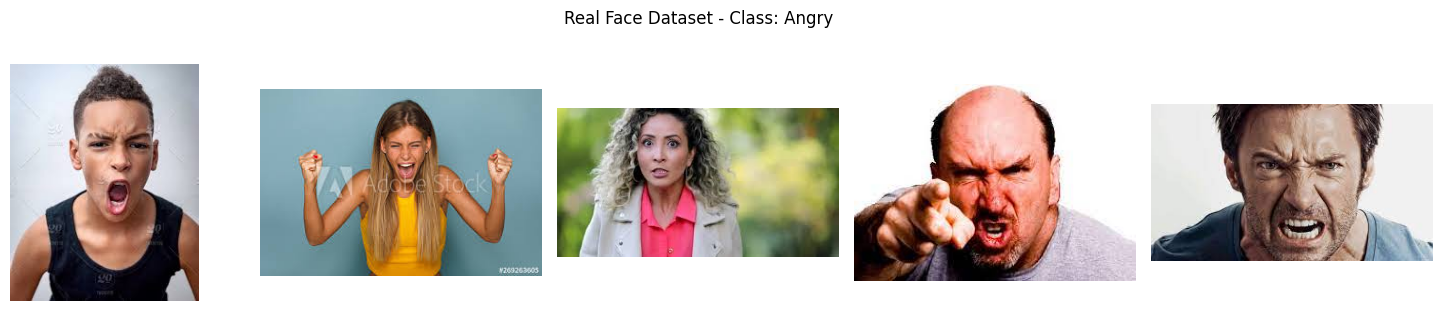

Displaying images for class: Happy


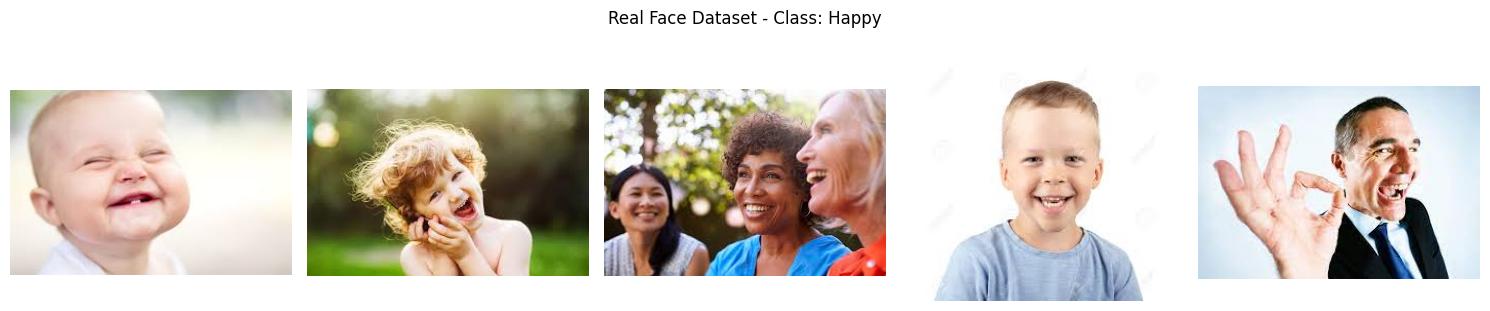

Displaying images for class: Sad


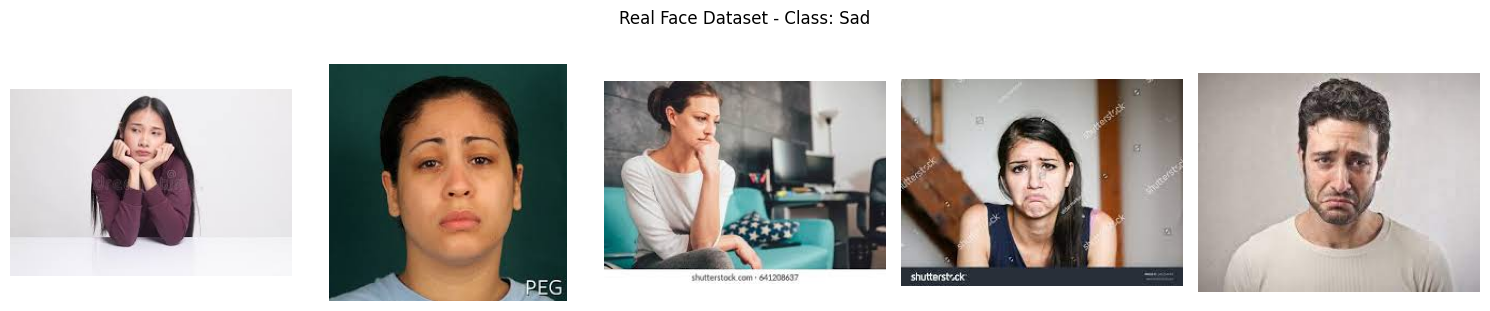

Displaying images for class: Neutral


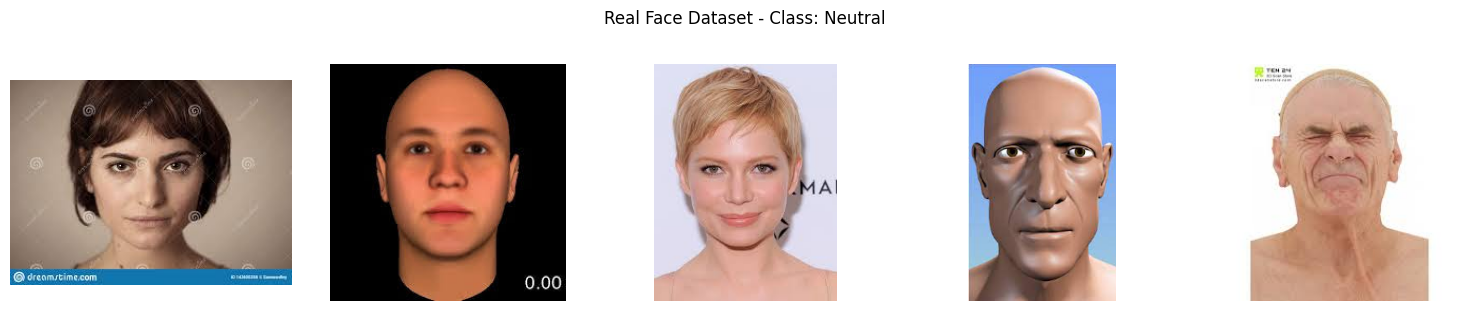

Displaying images for class: Surprise


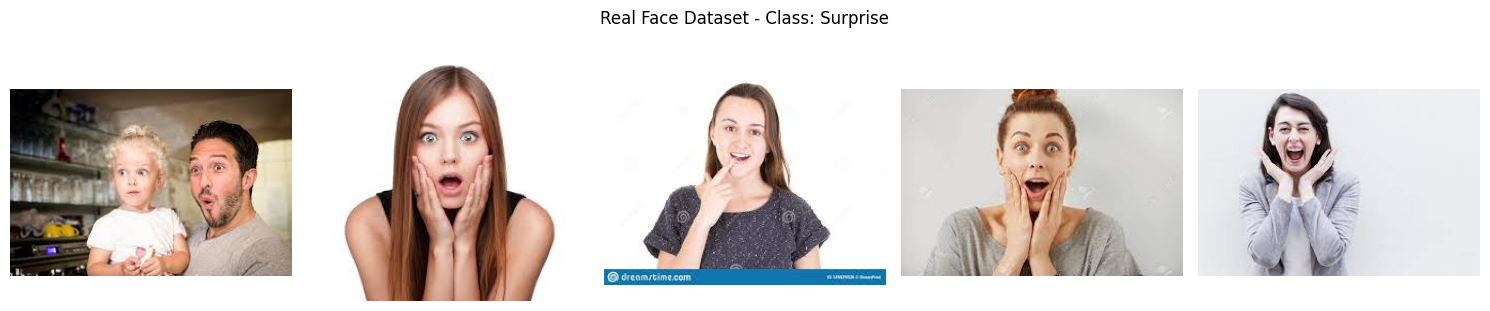

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Display images from the real face dataset
for class_name, image_paths in real_face_image_paths.items():
    print(f"Displaying images for class: {class_name}")
    num_images_to_display = min(5, len(image_paths))

    if num_images_to_display > 0:
        fig, axes = plt.subplots(1, num_images_to_display, figsize=(15, 3))
        if num_images_to_display == 1:
            axes = [axes] # Make it iterable even for a single image

        for i in range(num_images_to_display):
            img = mpimg.imread(image_paths[i])
            axes[i].imshow(img)
            axes[i].axis('off') # Hide axes

        fig.suptitle(f'Real Face Dataset - Class: {class_name}', y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No images found for class: {class_name}")


**Reasoning**:
Iterate through the image paths for each class in the synthetic data dataset and display the first 5 images or all if less than 5.



Displaying images for class: surprised


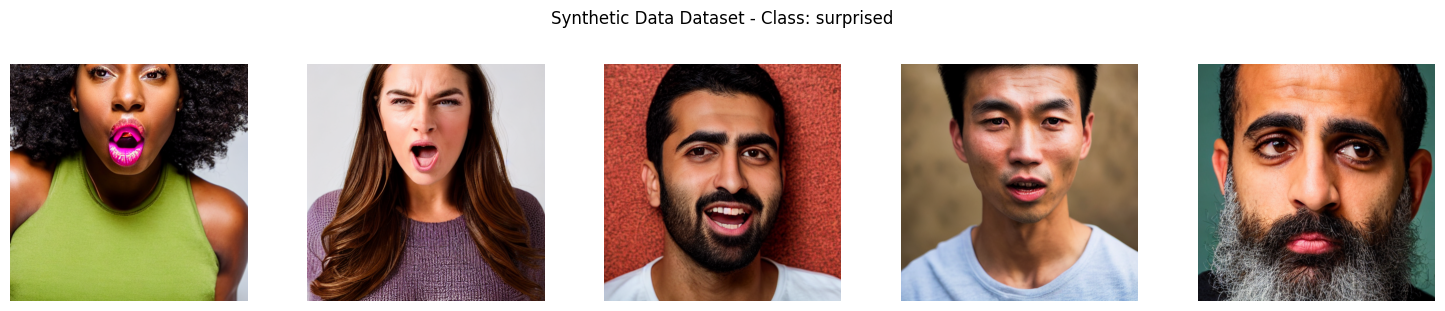

Displaying images for class: angry


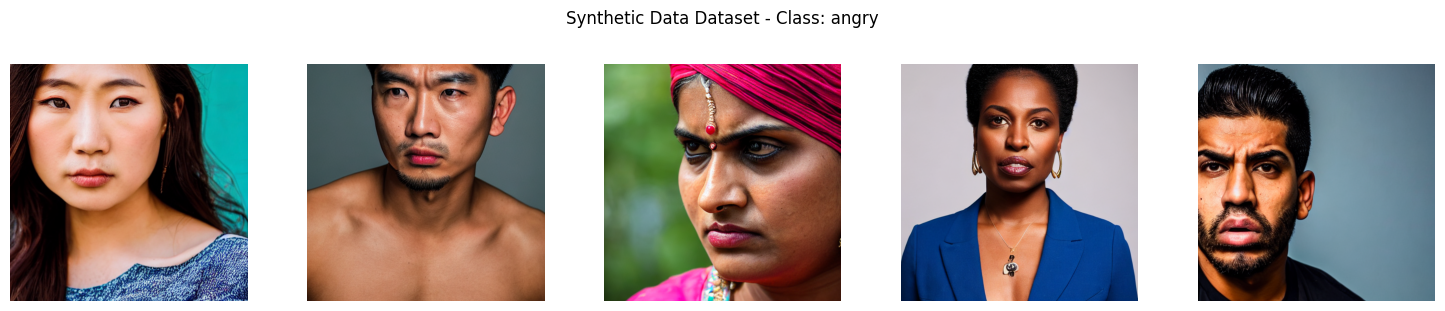

Displaying images for class: happy


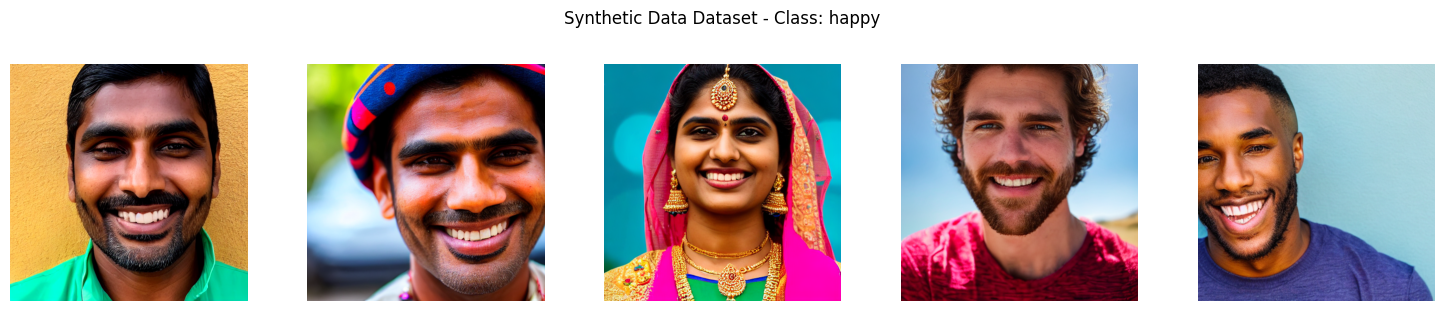

Displaying images for class: neutral


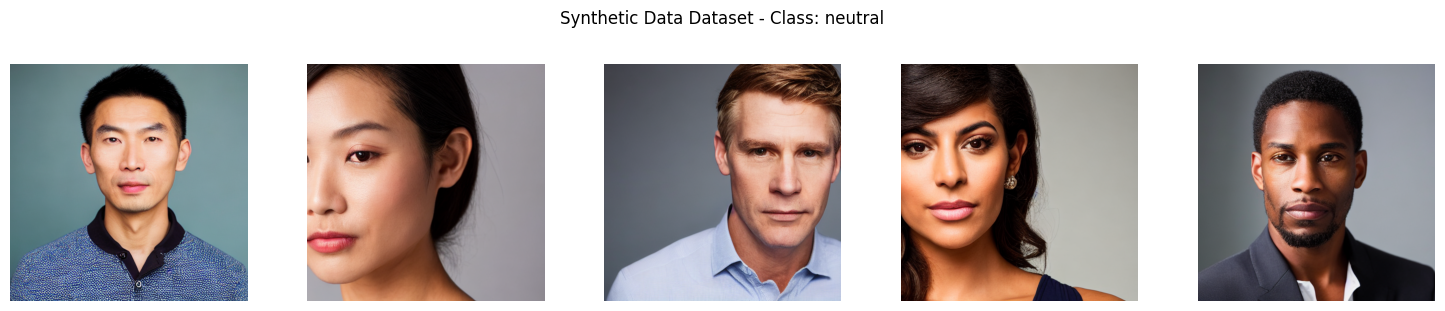

Displaying images for class: sad


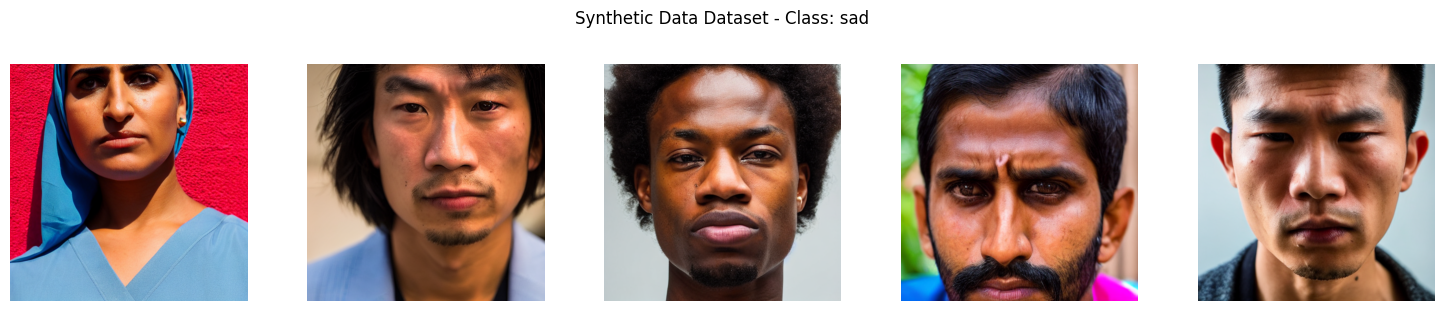

In [8]:
# Display images from the synthetic data dataset
for class_name, image_paths in synthetic_data_image_paths.items():
    print(f"Displaying images for class: {class_name}")
    num_images_to_display = min(5, len(image_paths))

    if num_images_to_display > 0:
        fig, axes = plt.subplots(1, num_images_to_display, figsize=(15, 3))
        if num_images_to_display == 1:
            axes = [axes] # Make it iterable even for a single image

        for i in range(num_images_to_display):
            img = mpimg.imread(image_paths[i])
            axes[i].imshow(img)
            axes[i].axis('off') # Hide axes

        fig.suptitle(f'Synthetic Data Dataset - Class: {class_name}', y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No images found for class: {class_name}")

In [9]:
# ==========================
# Emotion Recognition with Empathic-Insight-Face-Large
# Pretrain on Synthetic → Fine-tune on Real
# ==========================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from transformers import AutoModel, AutoConfig
import cv2
import numpy as np

In [ ]:
# ==========================
# 1. Device Setup
# ==========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================
# 2. Data Loaders
# ==========================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


Using device: cuda


In [11]:
# ----- Synthetic Dataset -----
synthetic_full = datasets.ImageFolder(root="/content/synthetic data", transform=transform)

# Split synthetic dataset: 70% train, 15% val, 15% test
synth_train_size = int(0.7 * len(synthetic_full))
synth_val_size = int(0.15 * len(synthetic_full))
synth_test_size = len(synthetic_full) - synth_train_size - synth_val_size
synthetic_train, synthetic_val, synthetic_test = random_split(synthetic_full, [synth_train_size, synth_val_size, synth_test_size])

synthetic_train_loader = DataLoader(synthetic_train, batch_size=32, shuffle=True)
synthetic_val_loader = DataLoader(synthetic_val, batch_size=32, shuffle=False)
synthetic_test_loader = DataLoader(synthetic_test, batch_size=32, shuffle=False)

In [13]:
# ----- Real Dataset -----
real_full = datasets.ImageFolder(root="/content/real face dataset", transform=transform)

# Split real dataset: 70% train, 15% val, 15% test
real_train_size = int(0.7 * len(real_full))
real_val_size = int(0.15 * len(real_full))
real_test_size = len(real_full) - real_train_size - real_val_size
real_train, real_val, real_test = random_split(real_full, [real_train_size, real_val_size, real_test_size])

real_train_loader = DataLoader(real_train, batch_size=32, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=32, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=32, shuffle=False)

num_classes = len(real_full.classes)
print("Classes:", real_full.classes, "| Total:", num_classes)

Classes: ['Angry', 'Happy', 'Neutral', 'Sad', 'Surprise'] | Total: 5


In [ ]:
# 3. Load Pretrained Model
# ==========================
model_name = "HardlyHumans/Facial-Expression-Detection"
config = AutoConfig.from_pretrained(model_name)
base_model = AutoModel.from_pretrained(model_name, config=config)

class EmotionModel(nn.Module):
    def __init__(self, base_model, num_classes, dropout_rate=0.5): # Added dropout_rate parameter
        super(EmotionModel, self).__init__()
        self.base = base_model
        hidden_size = base_model.config.hidden_size
        self.dropout = nn.Dropout(dropout_rate) # Added dropout layer
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        outputs = self.base(x)
        pooled = outputs.last_hidden_state[:, 0]
        pooled = self.dropout(pooled) # Apply dropout
        return self.classifier(pooled)

model = EmotionModel(base_model, num_classes).to(device) # Instantiate with default dropout_rate

Some weights of ViTModel were not initialized from the model checkpoint at HardlyHumans/Facial-Expression-Detection and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
# ==========================
# 4. Training Functions
# ==========================
criterion = nn.CrossEntropyLoss()

def train_model(model, train_loader, val_loader, optimizer, scheduler, epochs=5, save_path="model.pth", patience=3): # Added patience parameter
    best_acc = 0.0
    epochs_no_improve = 0 # Counter for early stopping

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        val_acc = evaluate_model(model, val_loader)

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {train_loss/len(train_loader):.4f} "
              f"| Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print("✅ Model Saved!")
            epochs_no_improve = 0 # Reset counter
        else:
            epochs_no_improve += 1 # Increment counter

        if epochs_no_improve == patience: # Check for early stopping
            print(f"Early stopping after {epoch+1} epochs due to no improvement in validation accuracy.")
            break

        scheduler.step()

def evaluate_model(model, data_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

In [24]:
# ==========================
# 5. Pretrain on Synthetic Dataset
# ==========================
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print("🔹 Pretraining on Synthetic Data...")
train_model(model, synthetic_train_loader, synthetic_val_loader, optimizer, scheduler, epochs=10, save_path="pretrained_synthetic.pth")

# Evaluate on synthetic test
model.load_state_dict(torch.load("pretrained_synthetic.pth"))
synth_test_acc = evaluate_model(model, synthetic_test_loader)
print("🎯 Synthetic Test Accuracy:", synth_test_acc)

🔹 Pretraining on Synthetic Data...
Epoch [1/10] | Loss: 1.0714 | Train Acc: 55.03% | Val Acc: 73.90%
✅ Model Saved!
Epoch [2/10] | Loss: 0.5561 | Train Acc: 78.78% | Val Acc: 78.98%
✅ Model Saved!
Epoch [3/10] | Loss: 0.3862 | Train Acc: 84.72% | Val Acc: 80.34%
✅ Model Saved!
Epoch [4/10] | Loss: 0.2612 | Train Acc: 91.31% | Val Acc: 81.02%
✅ Model Saved!
Epoch [5/10] | Loss: 0.2503 | Train Acc: 92.03% | Val Acc: 82.03%
✅ Model Saved!
Epoch [6/10] | Loss: 0.2401 | Train Acc: 93.05% | Val Acc: 82.03%
Epoch [7/10] | Loss: 0.2290 | Train Acc: 94.06% | Val Acc: 82.03%
Epoch [8/10] | Loss: 0.2155 | Train Acc: 94.06% | Val Acc: 82.03%
Early stopping after 8 epochs due to no improvement in validation accuracy.
🎯 Synthetic Test Accuracy: 82.15488215488216


In [25]:
# 6. Fine-tune on Real Dataset
# ==========================
print("🔹 Fine-tuning on Real Data...")
model.load_state_dict(torch.load("pretrained_synthetic.pth"), strict=False)

🔹 Fine-tuning on Real Data...


<All keys matched successfully>

In [28]:
# Freeze backbone
for param in model.base.parameters():
    param.requires_grad = False

optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

train_model(model, real_train_loader, real_val_loader, optimizer, scheduler, epochs=40, save_path="finetuned_real.pth")

Epoch [1/40] | Loss: 1.3520 | Train Acc: 47.43% | Val Acc: 45.95%
✅ Model Saved!
Epoch [2/40] | Loss: 1.3758 | Train Acc: 50.29% | Val Acc: 45.95%
Epoch [3/40] | Loss: 1.3448 | Train Acc: 44.57% | Val Acc: 45.95%
Epoch [4/40] | Loss: 1.3213 | Train Acc: 50.86% | Val Acc: 45.95%
Early stopping after 4 epochs due to no improvement in validation accuracy.


In [ ]:
# 1. Unfreeze last few layers of backbone
# Accessing parameters of the ViT model's encoder layers (blocks)
for name, param in model.base.named_parameters():
    # Assuming you want to unfreeze the last few encoder blocks,
    # the naming convention usually includes 'encoder.layer' followed by the block index.
    if 'encoder.layer' in name and any(f'encoder.layer.{i}.' in name for i in range(8, 12)): # Adjust range based on model size and desired layers
        param.requires_grad = True
        print(f"Unfreezing parameter: {name}")
    else:
        param.requires_grad = False

# 2. Different learning rates for backbone and classifier
# Adjust the optimizer to include parameters from the unfrozen backbone layers
unfrozen_params = [param for name, param in model.base.named_parameters() if param.requires_grad]
optimizer = optim.AdamW([
    {"params": unfrozen_params, "lr": 1e-5}, # Learning rate for unfrozen backbone layers
    {"params": model.classifier.parameters(), "lr": 1e-4}  # classifier learns faster
])

# 3. Cosine Annealing scheduler (better for fine-tuning)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

# 4. Training with augmentations (optional)
# Ensure transform is defined - it's defined in a previous cell (yggTERvQ_kgA)
# If you want to use a different transform for fine-tuning, define it here.
# For this fix, we'll assume the transform from yggTERvQ_kgA is being used or redefine as needed.
# Example of redefining transform with augmentations:
# transform = transforms.Compose([
#     transforms.RandomResizedCrop(224),
#     transforms.RandomHorizontalFlip(),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
# ])
# Update dataloaders if using a new transform:
# real_train_full = datasets.ImageFolder(root="/content/real face dataset", transform=transform)
# real_train, real_val, real_test = random_split(real_train_full, [real_train_size, real_val_size, real_test_size])
# real_train_loader = DataLoader(real_train, batch_size=32, shuffle=True)
# real_val_loader = DataLoader(real_val, batch_size=32, shuffle=False) # Keep validation transform consistent

# 5. Train model
train_model(model, real_train_loader, real_val_loader, optimizer, scheduler, epochs=20, save_path="finetuned_real.pth")

Unfreezing parameter: encoder.layer.8.attention.attention.query.weight
Unfreezing parameter: encoder.layer.8.attention.attention.query.bias
Unfreezing parameter: encoder.layer.8.attention.attention.key.weight
Unfreezing parameter: encoder.layer.8.attention.attention.key.bias
Unfreezing parameter: encoder.layer.8.attention.attention.value.weight
Unfreezing parameter: encoder.layer.8.attention.attention.value.bias
Unfreezing parameter: encoder.layer.8.attention.output.dense.weight
Unfreezing parameter: encoder.layer.8.attention.output.dense.bias
Unfreezing parameter: encoder.layer.8.intermediate.dense.weight
Unfreezing parameter: encoder.layer.8.intermediate.dense.bias
Unfreezing parameter: encoder.layer.8.output.dense.weight
Unfreezing parameter: encoder.layer.8.output.dense.bias
Unfreezing parameter: encoder.layer.8.layernorm_before.weight
Unfreezing parameter: encoder.layer.8.layernorm_before.bias
Unfreezing parameter: encoder.layer.8.layernorm_after.weight
Unfreezing parameter: encod

# Better Accuracy Without Overfitting

In [42]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets

# ---- 1. Partial unfreeze of ViT backbone ----
for name, param in model.base.named_parameters():
    # Unfreeze last 4 encoder blocks (adjust based on your model)
    if 'encoder.layer' in name and any(f'encoder.layer.{i}.' in name for i in range(8, 12)):
        param.requires_grad = True
    else:
        param.requires_grad = False

# ---- 2. Add dropout to classifier correctly ----
# Save the in_features before wrapping in Sequential
if not isinstance(model.classifier, nn.Sequential):
    if hasattr(model.classifier, "in_features"):
        in_features = model.classifier.in_features
        out_features = model.classifier.out_features if hasattr(model.classifier, "out_features") else model.classifier.out_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),  # 40% dropout
            nn.Linear(in_features, out_features)
        )
    else:
        raise ValueError("Cannot detect in_features of classifier. Check model.classifier structure.")

# ---- 3. Differential learning rates ----
unfrozen_params = [param for name, param in model.base.named_parameters() if param.requires_grad]
optimizer = optim.AdamW([
    {"params": unfrozen_params, "lr": 1e-5},         # backbone learns slowly
    {"params": model.classifier.parameters(), "lr": 1e-4}  # classifier learns faster
])

# ---- 4. Cosine Annealing scheduler with warm restart ----
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1, eta_min=1e-6)

# ---- 5. Data augmentation ----
transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Update dataloaders
real_train_full = datasets.ImageFolder(root="/content/real face dataset", transform=transform)
train_size = int(0.60 * len(real_train_full))
val_size = len(real_train_full) - train_size
real_train, real_val = random_split(real_train_full, [train_size, val_size])

real_train_loader = DataLoader(real_train, batch_size=32, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=32, shuffle=False)

# Ensure model is on the correct device before training
model.to(device)

# ---- 6. Train model ----
train_model(model, real_train_loader, real_val_loader, optimizer, scheduler, epochs=30, save_path="finetuned_real.pth")

Epoch [1/30] | Loss: 1.0172 | Train Acc: 59.33% | Val Acc: 63.00%
✅ Model Saved!
Epoch [2/30] | Loss: 1.0291 | Train Acc: 58.67% | Val Acc: 67.00%
✅ Model Saved!
Epoch [3/30] | Loss: 0.9541 | Train Acc: 61.33% | Val Acc: 68.00%
✅ Model Saved!
Epoch [4/30] | Loss: 0.9128 | Train Acc: 66.00% | Val Acc: 68.00%
Epoch [5/30] | Loss: 0.9681 | Train Acc: 61.33% | Val Acc: 66.00%
Epoch [6/30] | Loss: 0.9136 | Train Acc: 64.00% | Val Acc: 66.00%
Early stopping after 6 epochs due to no improvement in validation accuracy.


## Evaluate on Real Test Set

### Subtask:
Evaluate the fine-tuned model on the real test dataset.

**Reasoning**:
Load the best fine-tuned model and evaluate its accuracy on the real test data using the `evaluate_model` function.

In [43]:
# Evaluate on real test set
model.load_state_dict(torch.load("finetuned_real.pth"))
real_test_acc = evaluate_model(model, real_test_loader)
print("🎯 Real Test Accuracy:", real_test_acc)

🎯 Real Test Accuracy: 68.42105263157895


🔹 Predicting on image: /content/unseen/D2.jpeg
Predicted Emotion: Happy


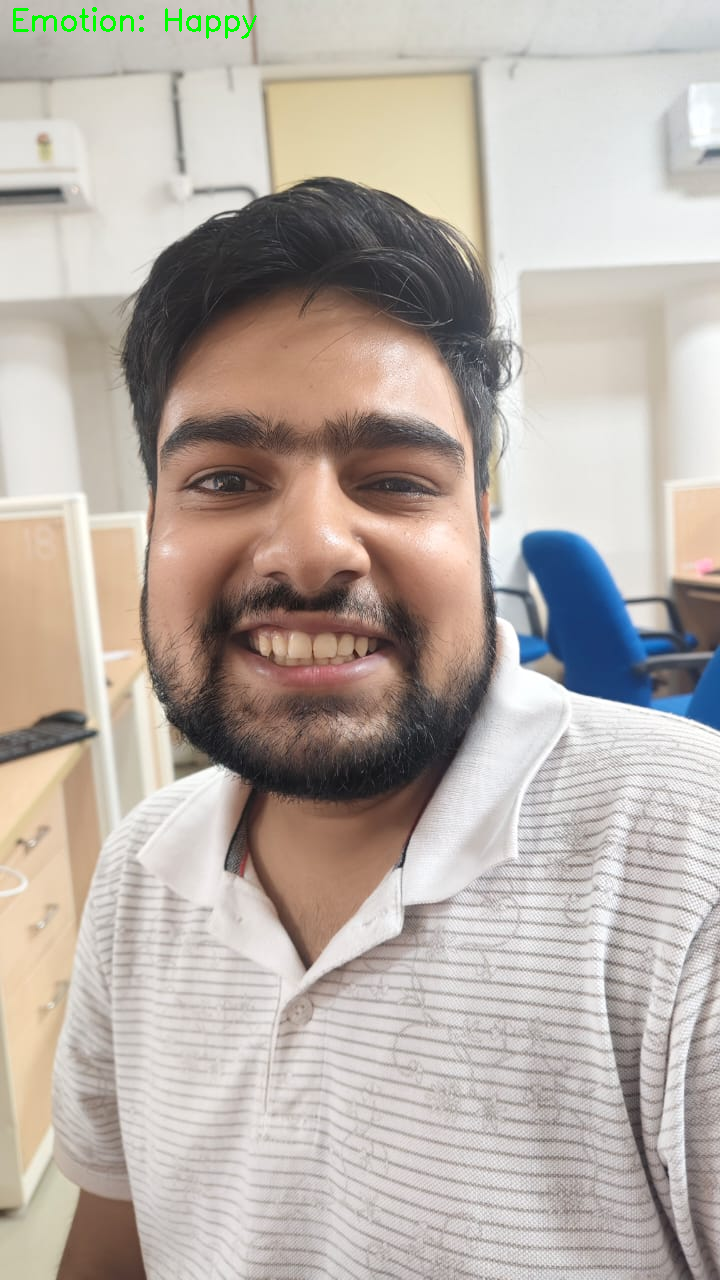

In [ ]:
# ==========================
# Check Unseen Data (Single Image)
# ==========================
import os
from PIL import Image
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Path to your unseen image
unseen_image_path = "/content/unseen/D2.jpeg" # Replace with the actual path to your image

# Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to(device)

print(f"🔹 Predicting on image: {unseen_image_path}")

# Load image with PIL
try:
    img_pil = Image.open(unseen_image_path).convert('RGB')
except FileNotFoundError:
    print(f"Error: Image not found at {unseen_image_path}")
    # You might want to add a way to upload an image here if it's not found
    # from google.colab import files
    # uploaded = files.upload()
    # ... handle upload and update unseen_image_path ...
    exit() # Exit if image not found for now

# Apply the same transform as used for fine-tuning (from cell U3bbUK41LE4J)
# Ensure transform_unseen is defined or define it here if needed
transform_unseen = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


img_tensor = transform_unseen(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(img_tensor)
    _, pred = torch.max(outputs, 1)
    # Ensure class_names is accessible - it was defined in cell _qq1xpjr_7RB
    label = real_full.classes[pred.item()]


print(f"Predicted Emotion: {label}")

# Convert PIL to OpenCV format for display
# Need to convert PIL (RGB) to OpenCV (BGR)
img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

# Add predicted label to the image
cv2.putText(img_cv, f"Emotion: {label}", (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# Use cv2_imshow instead of cv2.imshow
cv2_imshow(img_cv)

🔹 Predicting on image: /content/unseen/D1.jpeg
Predicted Emotion: Surprise


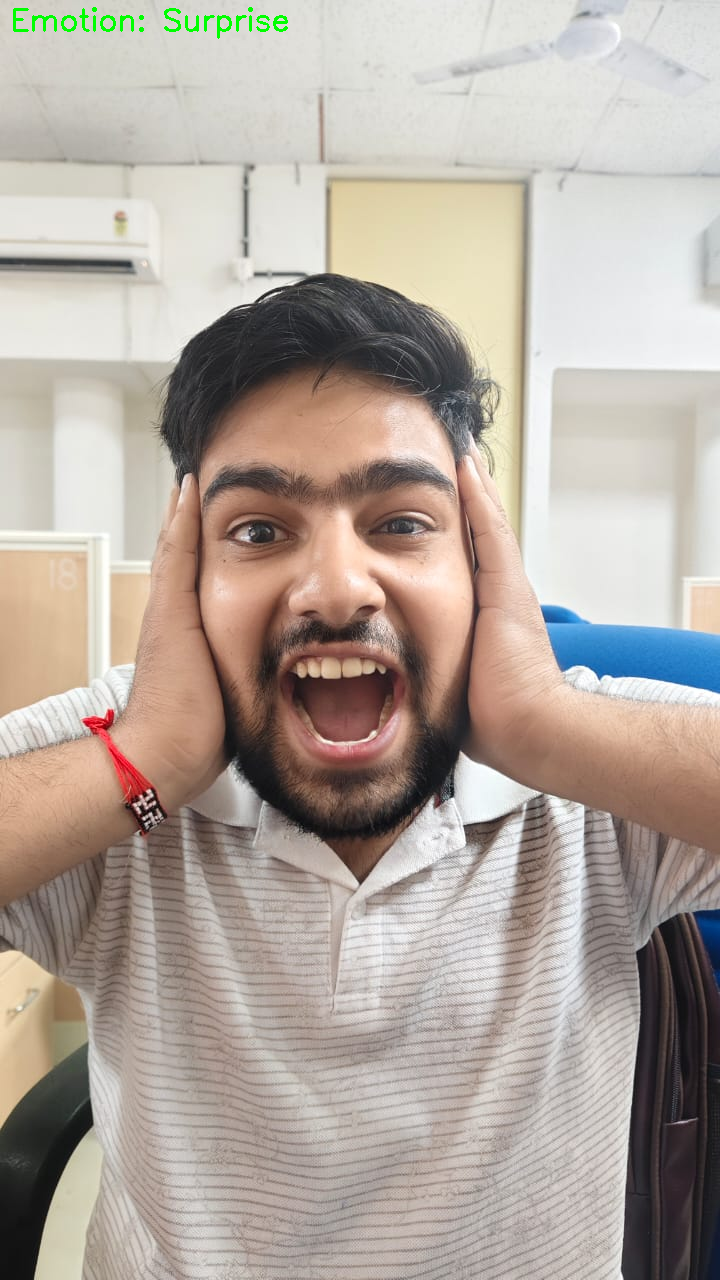

In [68]:
# ==========================
# Check Unseen Data (Single Image)
# ==========================
import os
from PIL import Image
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Path to your unseen image
unseen_image_path = "/content/unseen/D1.jpeg" # Replace with the actual path to your image

# Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to(device)

print(f"🔹 Predicting on image: {unseen_image_path}")

# Load image with PIL
try:
    img_pil = Image.open(unseen_image_path).convert('RGB')
except FileNotFoundError:
    print(f"Error: Image not found at {unseen_image_path}")
    # You might want to add a way to upload an image here if it's not found
    # from google.colab import files
    # uploaded = files.upload()
    # ... handle upload and update unseen_image_path ...
    exit() # Exit if image not found for now

# Apply the same transform as used for fine-tuning (from cell U3bbUK41LE4J)
# Ensure transform_unseen is defined or define it here if needed
transform_unseen = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


img_tensor = transform_unseen(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(img_tensor)
    _, pred = torch.max(outputs, 1)
    # Ensure class_names is accessible - it was defined in cell _qq1xpjr_7RB
    label = real_full.classes[pred.item()]


print(f"Predicted Emotion: {label}")

# Convert PIL to OpenCV format for display
# Need to convert PIL (RGB) to OpenCV (BGR)
img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

# Add predicted label to the image
cv2.putText(img_cv, f"Emotion: {label}", (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# Use cv2_imshow instead of cv2.imshow
cv2_imshow(img_cv)

🔹 Predicting on image: /content/angry-mans-face-expressing-fury_553340-531.jpg
Predicted Emotion: Angry


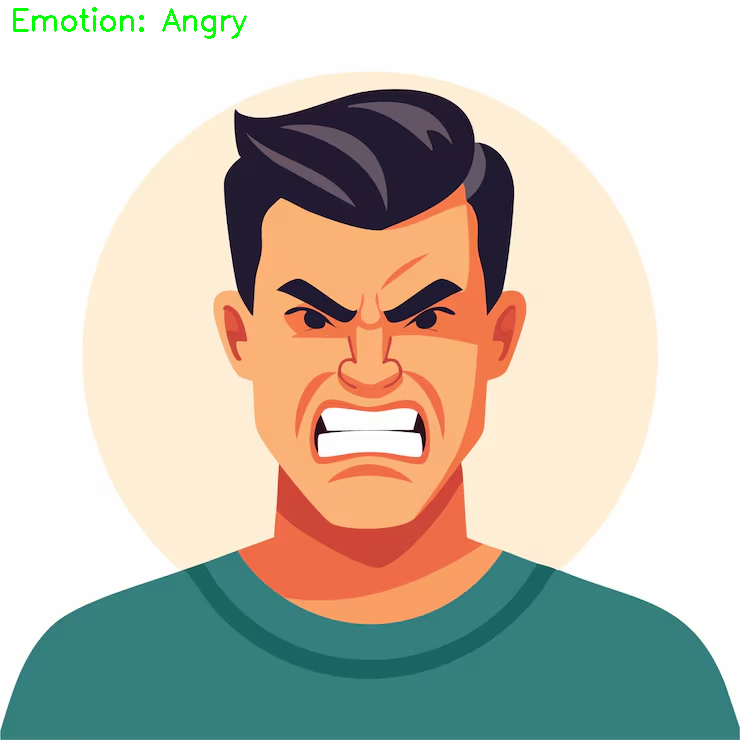

In [60]:
# ==========================
# Check Unseen Data (Single Image)
# ==========================
import os
from PIL import Image
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Path to your unseen image
unseen_image_path = "/content/angry-mans-face-expressing-fury_553340-531.jpg" # Replace with the actual path to your image

# Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to(device)

print(f"🔹 Predicting on image: {unseen_image_path}")

# Load image with PIL
try:
    img_pil = Image.open(unseen_image_path).convert('RGB')
except FileNotFoundError:
    print(f"Error: Image not found at {unseen_image_path}")
    # You might want to add a way to upload an image here if it's not found
    # from google.colab import files
    # uploaded = files.upload()
    # ... handle upload and update unseen_image_path ...
    exit() # Exit if image not found for now

# Apply the same transform as used for fine-tuning (from cell U3bbUK41LE4J)
# Ensure transform_unseen is defined or define it here if needed
transform_unseen = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


img_tensor = transform_unseen(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(img_tensor)
    _, pred = torch.max(outputs, 1)
    # Ensure class_names is accessible - it was defined in cell _qq1xpjr_7RB
    label = real_full.classes[pred.item()]


print(f"Predicted Emotion: {label}")

# Convert PIL to OpenCV format for display
# Need to convert PIL (RGB) to OpenCV (BGR)
img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

# Add predicted label to the image
cv2.putText(img_cv, f"Emotion: {label}", (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# Use cv2_imshow instead of cv2.imshow
cv2_imshow(img_cv)

🔹 Predicting on image: /content/png-male-angry-face-portrait-adult-photo_53876-902689.jpg
Predicted Emotion: Angry


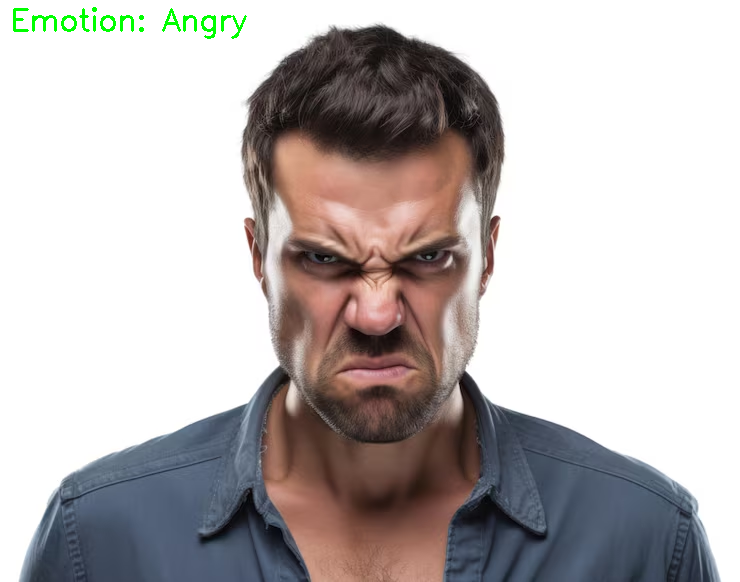

In [61]:
# ==========================
# Check Unseen Data (Single Image)
# ==========================
import os
from PIL import Image
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Path to your unseen image
unseen_image_path = "/content/png-male-angry-face-portrait-adult-photo_53876-902689.jpg" # Replace with the actual path to your image

# Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to(device)

print(f"🔹 Predicting on image: {unseen_image_path}")

# Load image with PIL
try:
    img_pil = Image.open(unseen_image_path).convert('RGB')
except FileNotFoundError:
    print(f"Error: Image not found at {unseen_image_path}")
    # You might want to add a way to upload an image here if it's not found
    # from google.colab import files
    # uploaded = files.upload()
    # ... handle upload and update unseen_image_path ...
    exit() # Exit if image not found for now

# Apply the same transform as used for fine-tuning (from cell U3bbUK41LE4J)
# Ensure transform_unseen is defined or define it here if needed
transform_unseen = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


img_tensor = transform_unseen(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(img_tensor)
    _, pred = torch.max(outputs, 1)
    # Ensure class_names is accessible - it was defined in cell _qq1xpjr_7RB
    label = real_full.classes[pred.item()]


print(f"Predicted Emotion: {label}")

# Convert PIL to OpenCV format for display
# Need to convert PIL (RGB) to OpenCV (BGR)
img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

# Add predicted label to the image
cv2.putText(img_cv, f"Emotion: {label}", (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# Use cv2_imshow instead of cv2.imshow
cv2_imshow(img_cv)